# 🚀 Train M2 Orientation Model on Google Colab

**Target**: Train ResNet18 + CBAM model for watermeter orientation prediction

## 📋 Overview

- **Dataset**: 49,994 train + 12,526 val samples with angle labels
- **Model**: ResNet18 + CBAM + Deep Regression Head
- **Target MAE**: < 2.0° (baseline), < 1.2° (with CSL later)
- **Training Time**: ~2-3 hours on Tesla T4

## ⚙️ Setup Instructions

1. Runtime → Change runtime type → GPU (Tesla T4)
2. Mount Google Drive
3. Upload/Link dataset
4. Run all cells

---

## 1️⃣ Mount Google Drive

Mount Drive to save training results and model checkpoints.

In [2]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2️⃣ Upload & Extract Dataset

### Upload Options:

**Option A: ZIP file (RECOMMENDED)**
1. Compress dataset as ZIP on your machine
2. Upload ZIP to Google Drive: `WaterMeter_Project/m2_rotated_dataset.zip`
3. Extract in Colab (this cell)

**Option B: Upload extracted folder**
1. Upload entire `m2_rotated_dataset/` folder to Google Drive
2. Skip extraction

### Expected Structure After Extraction:
```
WaterMeter_Project/
└── m2_rotated_dataset/
    ├── train/
    │   ├── images/     (49,994 images)
    │   └── labels.csv
    └── val/
        ├── images/     (12,526 images)
        └── labels.csv
```

In [ ]:
import pandas as pd
from pathlib import Path
import os

# Set the correct dataset path
COLAB_DATA_PATH = '/content/WaterMeter_Project/m2_rotated_dataset'

# Check CSV format
print("="*60)
print("CSV FORMAT DIAGNOSTIC")
print("="*60)
print(f"Dataset path: {COLAB_DATA_PATH}")

if not os.path.exists(COLAB_DATA_PATH):
    print(f"\n❌ Dataset not found at: {COLAB_DATA_PATH}")
    print(f"Please run Cell 3 (Upload & Extract Dataset) first!")
else:
    for split in ["train", "val"]:
        labels_file = Path(COLAB_DATA_PATH) / split / "labels.csv"

        if labels_file.exists():
            print(f"\n{split.upper()} - {labels_file}")
            print("-" * 60)

            # Read with pandas
            df = pd.read_csv(labels_file)

            print(f"Columns: {list(df.columns)}")
            print(f"Shape: {df.shape}")
            print(f"\nFirst 5 rows:")
            print(df.head())

            print(f"\nData types:")
            print(df.dtypes)

            print(f"\nStatistics (numeric columns):")
            print(df.describe())
        else:
            print(f"\n{split.upper()} - File not found: {labels_file}")

    print("\n" + "="*60)

CSV FORMAT DIAGNOSTIC
Dataset path: /content/WaterMeter_Project/m2_rotated_dataset

TRAIN - /content/WaterMeter_Project/m2_rotated_dataset/train/labels.csv
------------------------------------------------------------
Columns: ['filename', 'angle']
Shape: (49994, 2)

First 5 rows:
                                            filename   angle
0  crop_meter4_03907_9af88e4368594e9aaae6be8465a3...  286.46
1  crop_meter4_05084_c9c0d66a37054224adca08eb4188...  148.68
2  crop_meter4_05728_e1c6961a5e6f4a4a8c848248d239...   50.32
3  crop_meter4_01653_41b1718f406b4bbb9fb4e1d78bb5...   85.71
4  crop_meter4_04578_b5269001c33b4150988b96e56888...  199.62

Data types:
filename     object
angle       float64
dtype: object

Statistics (numeric columns):
              angle
count  49994.000000
mean     179.321222
std      103.710294
min        0.010000
25%       89.550000
50%      179.240000
75%      268.857500
max      360.000000

VAL - /content/WaterMeter_Project/m2_rotated_dataset/val/labels.csv
------

import numpy as np
from pathlib import Path
import pandas as pd
import os

# Set the correct dataset path
COLAB_DATA_PATH = '/content/WaterMeter_Project/m2_rotated_dataset'

def quick_verify_dataset(data_dir, split_name):
    """Verify dataset with robust CSV parsing"""
    labels_file = Path(data_dir) / "labels.csv"
    
    print(f"\n{'='*50}")
    print(f"{split_name} Dataset")
    print(f"{'='*50}")
    print(f"Checking: {labels_file}")
    
    if not labels_file.exists():
        print(f"❌ {split_name}: Labels not found at {labels_file}")
        print(f"\nSearching for labels file...")
        
        # Search for any CSV file in the directory
        parent_dir = Path(data_dir).parent
        csv_files = list(parent_dir.glob("**/*.csv"))
        print(f"Found CSV files: {csv_files}")
        return False
    
    try:
        # Try different CSV parsing methods
        print(f"✅ Labels file found!")
        
        # Method 1: Try pandas with various configurations
        angles = None
        
        # Try 1: Standard CSV with header
        try:
            df = pd.read_csv(labels_file)
            print(f"CSV columns: {list(df.columns)}")
            print(f"CSV shape: {df.shape}")
            
            # Find angle column (common names)
            angle_col = None
            for col in ['angle', 'rotation', 'rot', 'label', 'class']:
                if col in df.columns:
                    angle_col = col
                    break
            
            if angle_col:
                angles = df[angle_col].values
                print(f"✅ Read {len(angles)} angles from column '{angle_col}'")
            else:
                # Try second column if exists
                if len(df.columns) >= 2:
                    angles = df.iloc[:, 1].values
                    print(f"✅ Read {len(angles)} angles from column 1")
                else:
                    angles = df.iloc[:, 0].values
                    print(f"✅ Read {len(angles)} angles from column 0")
        except Exception as e:
            print(f"⚠️  Pandas error: {e}")
            
            # Method 2: Manual parsing
            angles = []
            with open(labels_file, 'r') as f:
                lines = f.readlines()
                
                # Check if first line is header
                first_line_parts = lines[0].strip().split(',')
                has_header = False
                try:
                    float(first_line_parts[-1])
                except ValueError:
                    has_header = True
                
                start_idx = 1 if has_header else 0
                
                for line in lines[start_idx:]:
                    parts = line.strip().split(',')
                    if len(parts) >= 1:
                        try:
                            # Try last column as angle
                            angle = float(parts[-1])
                            angles.append(angle)
                        except:
                            continue
            
            angles = np.array(angles)
            print(f"✅ Manually parsed {len(angles)} angles")
        
        if angles is None or len(angles) == 0:
            print(f"❌ No valid angles found")
            return False
        
        # Statistics
        print(f"\n📊 Statistics:")
        print(f"  Samples: {len(angles):,}")
        print(f"  Angle range: [{angles.min():.1f}°, {angles.max():.1f}°]")
        print(f"  Mean: {angles.mean():.1f}°, Std: {angles.std():.1f}°")
        
        # Check uniformity
        hist, _ = np.histogram(angles, bins=36, range=(0, 360))
        ratio = hist.max() / (hist.min() + 1e-6)
        print(f"  Uniformity ratio: {ratio:.2f}", end="")
        
        if ratio < 3.0:
            print(" ✅")
        else:
            print(" ⚠️  (not uniform)")
        
        # Show first few samples
        print(f"\n  Sample angles: {angles[:5].tolist()}...")
        
        return True
        
    except Exception as e:
        print(f"❌ Error reading labels: {e}")
        import traceback
        traceback.print_exc()
        return False


# Verify both splits
print("\n" + "="*60)
print("DATASET VERIFICATION")
print("="*60)
print(f"Dataset path: {COLAB_DATA_PATH}")

if not os.path.exists(COLAB_DATA_PATH):
    print(f"\n❌ Dataset not found at: {COLAB_DATA_PATH}")
    print(f"Please run Cell 3 (Upload & Extract Dataset) first!")
else:
    train_ok = quick_verify_dataset(f"{COLAB_DATA_PATH}/train", "TRAIN")
    val_ok = quick_verify_dataset(f"{COLAB_DATA_PATH}/val", "VAL")

    if train_ok and val_ok:
        print("\n" + "="*60)
        print("✅ Dataset is ready for training!")
        print("="*60)
    else:
        print("\n" + "="*60)
        print("❌ Dataset issues found. Please check data.")
        print("="*60)

In [ ]:
import os
import zipfile
import shutil
from pathlib import Path

# Dataset paths - UPDATED to correct paths
DRIVE_ZIP_PATH = '/content/drive/MyDrive/WaterMeter_Project/m2_rotated_dataset.zip'
DRIVE_DATA_PATH = '/content/drive/MyDrive/WaterMeter_Project/m2_rotated_dataset'
COLAB_DATA_PATH = '/content/WaterMeter_Project/m2_rotated_dataset'

print("="*60)
print("DATASET EXTRACTION")
print("="*60)

# Create WaterMeter_Project directory
os.makedirs('/content/WaterMeter_Project', exist_ok=True)

# Method 1: Extract from ZIP (recommended)
if os.path.exists(DRIVE_ZIP_PATH):
    print(f"✅ Found ZIP file: {DRIVE_ZIP_PATH}")

    # Get ZIP size
    zip_size = os.path.getsize(DRIVE_ZIP_PATH) / (1024**3)
    print(f"📦 ZIP size: {zip_size:.2f} GB")
    print(f"📦 Extracting...")

    # Extract to WaterMeter_Project directory
    with zipfile.ZipFile(DRIVE_ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall('/content/WaterMeter_Project/')

    print(f"✅ Extraction complete!")
    print(f"📁 Dataset location: {COLAB_DATA_PATH}")

# Method 2: Copy from Google Drive (if already extracted)
elif os.path.exists(DRIVE_DATA_PATH):
    print(f"✅ Found extracted dataset in Drive: {DRIVE_DATA_PATH}")

    # Create symlink in Colab
    if os.path.exists(COLAB_DATA_PATH):
        os.remove(COLAB_DATA_PATH)
    os.symlink(DRIVE_DATA_PATH, COLAB_DATA_PATH)

    print(f"✅ Dataset linked: {COLAB_DATA_PATH}")

# Method 3: Check if already extracted in Colab
elif os.path.exists(COLAB_DATA_PATH):
    print(f"✅ Dataset already exists: {COLAB_DATA_PATH}")

else:
    print(f"❌ Dataset not found!")
    print(f"\nPlease upload one of these to Google Drive:")
    print(f"  1. WaterMeter_Project/m2_rotated_dataset.zip (recommended)")
    print(f"  2. WaterMeter_Project/m2_rotated_dataset/ folder (extracted)")
    print(f"\nThen run this cell again.")

# Verify dataset structure
if os.path.exists(COLAB_DATA_PATH):
    print(f"\n" + "="*60)
    print("DATASET STRUCTURE")
    print("="*60)

    for split in ['train', 'val']:
        split_path = os.path.join(COLAB_DATA_PATH, split)
        if os.path.exists(split_path):
            labels_file = os.path.join(split_path, 'labels.csv')
            images_dir = os.path.join(split_path, 'images')

            print(f"\n{split.upper()}: {split_path}")
            print(f"  - labels.csv: {'✅' if os.path.exists(labels_file) else '❌'}")
            print(f"  - images/: {'✅' if os.path.exists(images_dir) else '❌'}")

            if os.path.exists(images_dir):
                num_images = len([f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.png', '.jpeg'))])
                print(f"  - Number of images: {num_images:,}")

            if os.path.exists(labels_file):
                import pandas as pd
                df = pd.read_csv(labels_file)
                print(f"  - CSV shape: {df.shape}")
                print(f"  - CSV columns: {list(df.columns)}")
        else:
            print(f"\n{split.upper()}: ❌ Not found")

    print(f"\n" + "="*60)

DATASET EXTRACTION
✅ Found ZIP file: /content/drive/MyDrive/WaterMeter_Project/m2_rotated_dataset.zip
📦 ZIP size: 1.48 GB
📦 Extracting...
✅ Extraction complete!
📁 Dataset location: /content/WaterMeter_Project/m2_rotated_dataset

DATASET STRUCTURE

TRAIN: /content/WaterMeter_Project/m2_rotated_dataset/train
  - labels.csv: ✅
  - images/: ✅
  - Number of images: 49,994
  - CSV shape: (49994, 2)
  - CSV columns: ['filename', 'angle']

VAL: /content/WaterMeter_Project/m2_rotated_dataset/val
  - labels.csv: ✅
  - images/: ✅
  - Number of images: 12,526
  - CSV shape: (12526, 2)
  - CSV columns: ['filename', 'angle']



## 3️⃣ CSV Format Diagnostic (Run this first to check your CSV structure)

## 4️⃣ Verify Dataset Quality (After checking CSV format above)

## 5️⃣ Install Dependencies

In [ ]:
# Install required packages
print("Installing dependencies...")

!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118 -q
!pip install ultralytics opencv-python-headless pillow tqdm -q

import torch
import torchvision

print(f"\n✅ PyTorch: {torch.__version__}")
print(f"✅ TorchVision: {torchvision.__version__}")
print(f"✅ CUDA Available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
    print(f"✅ VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print("⚠️  No GPU detected! Training will be very slow.")

Installing dependencies...

✅ PyTorch: 2.10.0+cu128
✅ TorchVision: 0.25.0+cu128
✅ CUDA Available: True
✅ GPU: Tesla T4
✅ VRAM: 14.6 GB


## 6️⃣ Create Training Scripts

In [ ]:
%%writefile /content/improve_m2_model.py
"""M2 Model Improvements - CBAM, Loss Functions"""
import torch
import torch.nn as nn
import torch.nn.functional as F


class M2Backbone(nn.Module):
    """M2 Backbone wrapper"""
    def __init__(self, backbone: str = "resnet18", pretrained: bool = True):
        super().__init__()
        import torchvision.models as models

        if backbone == "resnet18":
            resnet = models.resnet18(weights='DEFAULT' if pretrained else None)
            self.features = nn.Sequential(*list(resnet.children())[:-2])
        else:
            raise ValueError(f"Unsupported backbone: {backbone}")

    def forward(self, x):
        return self.features(x)


class CBAM(nn.Module):
    """Convolutional Block Attention Module"""
    def __init__(self, in_channels: int, reduction: int = 16):
        super().__init__()

        # Channel Attention
        self.channel_att = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, in_channels // reduction, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels // reduction, in_channels, 1),
        )

        # Spatial Attention
        self.spatial_att = nn.Sequential(
            nn.Conv2d(2, 1, kernel_size=7, padding=3),
            nn.Sigmoid()
        )

    def forward(self, x):
        # Channel attention
        ca = self.channel_att(x)
        ca = torch.sigmoid(ca)
        x = x * ca

        # Spatial attention
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        sa_input = torch.cat([avg_out, max_out], dim=1)
        sa = self.spatial_att(sa_input)
        x = x * sa

        return x


class CombinedLoss(nn.Module):
    """Combined MSE + Angular loss"""
    def __init__(self, mse_weight: float = 0.5, angular_weight: float = 0.5):
        super().__init__()
        self.mse_weight = mse_weight
        self.angular_weight = angular_weight
        self.mse = nn.MSELoss()

    def forward(self, pred, target):
        mse_loss = self.mse(pred, target)
        angular_loss = 1 - F.cosine_similarity(pred, target, dim=1).mean()
        return self.mse_weight * mse_loss + self.angular_weight * angular_loss

print("✅ Created improve_m2_model.py")

Overwriting /content/improve_m2_model.py


In [ ]:
%%writefile /content/m2_utils.py
"""M2 Utility Functions"""
import torch


def angle_to_sin_cos(angle_degrees: torch.Tensor) -> torch.Tensor:
    """Convert angle in degrees to sin/cos values"""
    angles_rad = torch.deg2rad(angle_degrees)
    sin_val = torch.sin(angles_rad)
    cos_val = torch.cos(angles_rad)
    return torch.stack([sin_val, cos_val], dim=1)


def sin_cos_to_angle(sin_cos: torch.Tensor) -> torch.Tensor:
    """Convert sin/cos to angle in degrees [0, 360)"""
    sin_val = sin_cos[:, 0]
    cos_val = sin_cos[:, 1]
    angles_rad = torch.atan2(sin_val, cos_val)
    angles_deg = torch.rad2deg(angles_rad)
    angles_deg = (angles_deg + 360) % 360
    return angles_deg


def compute_circular_mae(pred_angles: torch.Tensor, target_angles: torch.Tensor) -> float:
    """Compute circular MAE"""
    diff = torch.abs(pred_angles - target_angles)
    diff = torch.minimum(diff, 360 - diff)
    return diff.mean().item()

print("✅ Created m2_utils.py")

Overwriting /content/m2_utils.py


In [ ]:
%%writefile /content/train_m2_colab.py
"""M2 Training Script for Colab - ResNet18 + CBAM (FIXED)"""
import os
import json
import logging
from pathlib import Path
from tqdm import tqdm
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from torchvision import transforms
from PIL import Image
import pandas as pd

# Import modules
import sys
sys.path.insert(0, '/content')
from m2_utils import angle_to_sin_cos, sin_cos_to_angle, compute_circular_mae
from improve_m2_model import M2Backbone, CBAM, CombinedLoss

logging.basicConfig(level=logging.INFO, format='%(asctime)s | %(levelname)s | %(message)s')
logger = logging.getLogger(__name__)


class MeterAngleDatasetCSV(Dataset):
    """Dataset with robust CSV parsing"""
    def __init__(self, images_dir: str, labels_file: str, split: str = "train"):
        self.images_dir = Path(images_dir)
        self.samples = []

        logger.info(f"Loading labels from: {labels_file}")

        # Try multiple parsing methods
        df = None
        try:
            # Method 1: Standard pandas read
            df = pd.read_csv(labels_file)
            logger.info(f"CSV columns: {list(df.columns)}")

            # Find angle column
            angle_col = None
            for col in ['angle', 'rotation', 'rot', 'label', 'class']:
                if col in df.columns:
                    angle_col = col
                    break

            if angle_col:
                df['angle'] = df[angle_col]
            elif len(df.columns) >= 2:
                # Assume second column is angle
                df['angle'] = df.iloc[:, 1]
            else:
                df['angle'] = df.iloc[:, 0]

            # Get filename column
            filename_col = None
            for col in ['filename', 'image', 'img', 'name', 'file', 'path']:
                if col in df.columns:
                    filename_col = col
                    break

            if filename_col:
                df['filename'] = df[filename_col]
            else:
                # First column is filename
                df['filename'] = df.iloc[:, 0]

            # Create samples
            for _, row in df.iterrows():
                filename = str(row['filename']).strip()
                angle = float(row['angle'])

                # Check if file exists
                img_path = self.images_dir / filename
                if img_path.exists():
                    self.samples.append((filename, angle))
                else:
                    logger.debug(f"Image not found: {img_path}")

            logger.info(f"Loaded {len(self.samples)} samples from CSV")

        except Exception as e:
            logger.warning(f"Pandas parsing failed: {e}, trying manual parsing...")

            # Method 2: Manual parsing
            with open(labels_file, 'r') as f:
                lines = f.readlines()

                # Check for header
                if lines:
                    first_parts = lines[0].strip().split(',')
                    try:
                        float(first_parts[-1])
                        start_idx = 0  # No header
                    except ValueError:
                        start_idx = 1  # Has header
                else:
                    start_idx = 0

                for line in lines[start_idx:]:
                    parts = line.strip().split(',')
                    if len(parts) >= 2:
                        try:
                            filename = parts[0].strip()
                            angle = float(parts[-1])  # Last column is angle

                            img_path = self.images_dir / filename
                            if img_path.exists():
                                self.samples.append((filename, angle))
                        except Exception as ex:
                            logger.debug(f"Skipping line: {ex}")
                            continue

            logger.info(f"Loaded {len(self.samples)} samples manually")

        if len(self.samples) == 0:
            raise ValueError(f"No valid samples found in {labels_file}")

        logger.info(f"Total samples: {len(self.samples)}")

        if split == "train":
            self.transform = transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.RandomRotation(5),  # FIXED: Reduced from 30°
                transforms.ColorJitter(brightness=0.1, contrast=0.1),
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
            ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        filename, angle = self.samples[idx]
        img = Image.open(self.images_dir / filename).convert('RGB')
        img = self.transform(img)

        angle_tensor = torch.tensor([angle], dtype=torch.float32)
        sin_cos_label = angle_to_sin_cos(angle_tensor).squeeze(0)
        return img, sin_cos_label


class M2ResNet18CBAM(nn.Module):
    """ResNet18 + CBAM Model"""
    def __init__(self, pretrained: bool = True, dropout: float = 0.4):
        super().__init__()
        self.backbone = M2Backbone("resnet18", pretrained)
        self.cbam = CBAM(512, reduction=16)
        self.gap = nn.AdaptiveAvgPool2d(1)

        self.regressor = nn.Sequential(
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.6),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        features = self.backbone(x)
        features = self.cbam(features)
        features = self.gap(features).flatten(1)
        sin_cos = self.regressor(features)
        return nn.functional.normalize(sin_cos, p=2, dim=1)


class Trainer:
    """Trainer class"""
    def __init__(self, model, train_loader, val_loader, output_dir):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.output_dir = Path(output_dir)
        self.output_dir.mkdir(parents=True, exist_ok=True)

        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model.to(self.device)

        self.optimizer = optim.AdamW(model.parameters(), lr=3e-5, weight_decay=1e-4)
        # FIXED: Removed 'verbose' parameter (not supported in all PyTorch versions)
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', factor=0.5, patience=10
        )
        self.loss_fn = CombinedLoss(mse_weight=0.5, angular_weight=0.5)
        self.scaler = GradScaler() if torch.cuda.is_available() else None

        self.best_val_mae = float('inf')
        self.history = {'train_loss': [], 'val_loss': [], 'val_mae': [], 'lr': []}

        logger.info(f"Training on: {self.device}")

    def train_epoch(self, epoch):
        self.model.train()
        total_loss = 0.0
        for images, labels in tqdm(self.train_loader, desc=f"Epoch {epoch}"):
            images, labels = images.to(self.device), labels.to(self.device)
            self.optimizer.zero_grad()

            if self.scaler:
                with autocast():
                    outputs = self.model(images)
                    loss = self.loss_fn(outputs, labels)
                self.scaler.scale(loss).backward()
                self.scaler.unscale_(self.optimizer)
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                self.scaler.step(self.optimizer)
                self.scaler.update()
            else:
                outputs = self.model(images)
                loss = self.loss_fn(outputs, labels)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                self.optimizer.step()

            total_loss += loss.item()
        return total_loss / len(self.train_loader)

    @torch.no_grad()
    def validate(self):
        self.model.eval()
        total_loss = 0.0
        all_pred, all_target = [], []

        for images, labels in tqdm(self.val_loader, desc="Validating"):
            images, labels = images.to(self.device), labels.to(self.device)
            outputs = self.model(images)
            loss = self.loss_fn(outputs, labels)
            total_loss += loss.item()

            all_pred.append(sin_cos_to_angle(outputs).cpu())
            all_target.append(sin_cos_to_angle(labels).cpu())

        avg_loss = total_loss / len(self.val_loader)
        mae = compute_circular_mae(torch.cat(all_pred), torch.cat(all_target))
        return avg_loss, mae

    def fit(self, epochs=50):
        logger.info(f"Starting training for {epochs} epochs...")
        patience = 20
        patience_counter = 0

        for epoch in range(1, epochs + 1):
            train_loss = self.train_epoch(epoch)
            val_loss, val_mae = self.validate()
            self.scheduler.step(val_mae)

            lr = self.optimizer.param_groups[0]['lr']
            logger.info(f"Epoch {epoch}/{epochs}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, val_mae={val_mae:.2f}°, lr={lr:.2e}")

            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['val_mae'].append(val_mae)
            self.history['lr'].append(lr)

            with open(self.output_dir / "history.json", 'w') as f:
                json.dump(self.history, f, indent=2)

            if epoch % 5 == 0:
                torch.save({'epoch': epoch, 'model_state_dict': self.model.state_dict(), 'val_mae': val_mae},
                          self.output_dir / f"checkpoint_epoch_{epoch}.pth")

            if val_mae < self.best_val_mae:
                self.best_val_mae = val_mae
                torch.save(self.model.state_dict(), self.output_dir / "best_model.pth")
                logger.info(f"✅ Best model saved (MAE: {val_mae:.2f}°)")
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= patience:
                logger.info(f"Early stopping! Best MAE: {self.best_val_mae:.2f}°")
                break

        logger.info(f"Training complete! Best MAE: {self.best_val_mae:.2f}°")


def main():
    import argparse
    parser = argparse.ArgumentParser()
    # UPDATED: Default paths to match Colab structure
    parser.add_argument("--train_dir", type=str, default="/content/WaterMeter_Project/m2_rotated_dataset/train")
    parser.add_argument("--val_dir", type=str, default="/content/WaterMeter_Project/m2_rotated_dataset/val")
    parser.add_argument("--output_dir", type=str, default="/content/drive/MyDrive/WaterMeterAI/M2_Training/outputs")
    parser.add_argument("--batch_size", type=int, default=32)
    parser.add_argument("--epochs", type=int, default=50)
    args = parser.parse_args()

    model = M2ResNet18CBAM(pretrained=True, dropout=0.4)

    train_dataset = MeterAngleDatasetCSV(f"{args.train_dir}/images", f"{args.train_dir}/labels.csv", "train")
    val_dataset = MeterAngleDatasetCSV(f"{args.val_dir}/images", f"{args.val_dir}/labels.csv", "val")

    train_loader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=args.batch_size, shuffle=False, num_workers=2, pin_memory=True)

    logger.info(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}")

    trainer = Trainer(model, train_loader, val_loader, args.output_dir)
    trainer.fit(epochs=args.epochs)

if __name__ == "__main__":
    main()

print("✅ Created train_m2_colab.py")

Overwriting /content/train_m2_colab.py


## 7️⃣ Start Training

In [ ]:
# Start training
print("\n" + "="*60)
print("🚀 STARTING M2 TRAINING")
print("="*60)
print("\nConfiguration:")
print(f"  Train samples: 49,994")
print(f"  Val samples: 12,526")
print(f"  Batch size: 32")
print(f"  Learning rate: 3e-5")
print(f"  Epochs: 50 (with early stopping)")
print(f"\nExpected training time: 2-3 hours on Tesla T4")
print("\n" + "="*60 + "\n")

!python /content/train_m2_colab.py --epochs 20 --batch_size 32

print("\n" + "="*60)
print("✅ TRAINING COMPLETE")
print("="*60)


🚀 STARTING M2 TRAINING

Configuration:
  Train samples: 49,994
  Val samples: 12,526
  Batch size: 32
  Learning rate: 3e-5
  Epochs: 50 (with early stopping)

Expected training time: 2-3 hours on Tesla T4


✅ Created m2_utils.py
✅ Created improve_m2_model.py
2026-02-25 03:01:06,844 | INFO | Loading labels from: /content/WaterMeter_Project/m2_rotated_dataset/train/labels.csv
2026-02-25 03:01:06,941 | INFO | CSV columns: ['filename', 'angle']
2026-02-25 03:01:11,920 | INFO | Loaded 49994 samples from CSV
2026-02-25 03:01:11,920 | INFO | Total samples: 49994
2026-02-25 03:01:11,922 | INFO | Loading labels from: /content/WaterMeter_Project/m2_rotated_dataset/val/labels.csv
2026-02-25 03:01:11,946 | INFO | CSV columns: ['filename', 'angle']
2026-02-25 03:01:13,130 | INFO | Loaded 12526 samples from CSV
2026-02-25 03:01:13,130 | INFO | Total samples: 12526
2026-02-25 03:01:13,131 | INFO | Train: 49994, Val: 12526
/content/train_m2_colab.py:198: FutureWarning: `torch.cuda.amp.GradScaler(arg

## 8️⃣ Training Results Analysis

/tmp/ipython-input-261893693.py:53: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipython-input-261893693.py:54: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('/content/drive/MyDrive/WaterMeterAI/M2_Training/training_curves.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


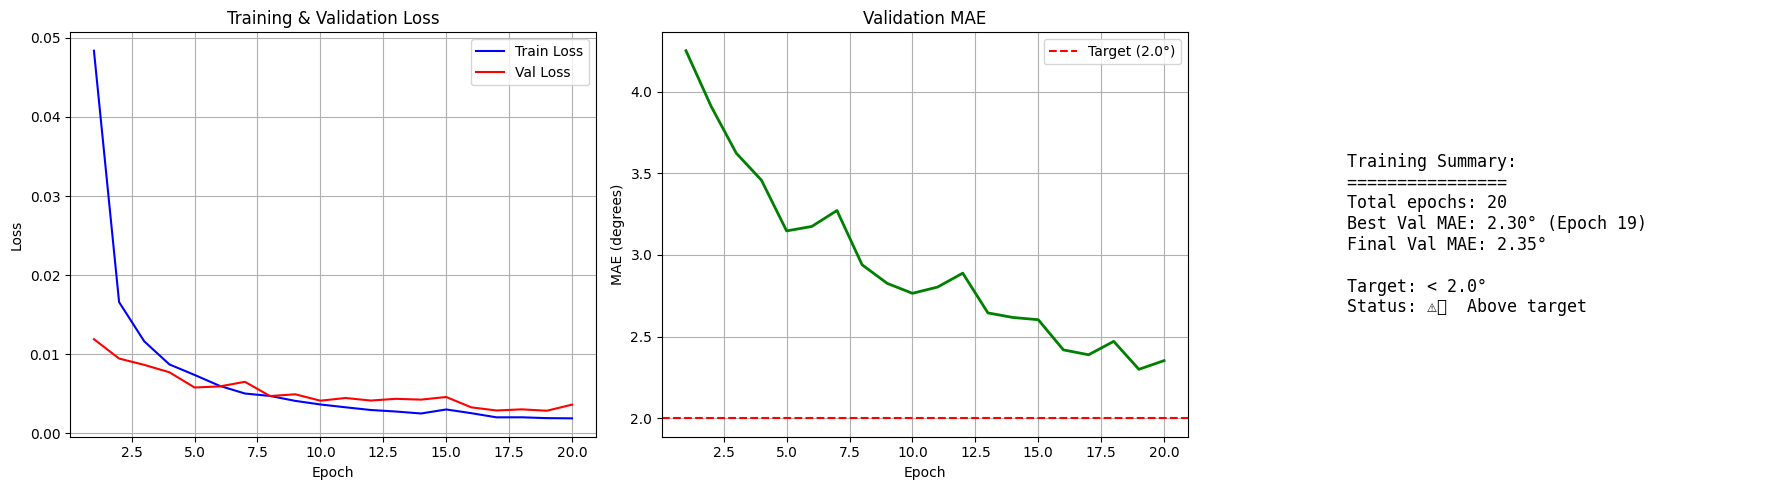


TRAINING SUMMARY
Total epochs: 20
Best Val MAE: 2.30° (Epoch 19)
Final Val MAE: 2.35°

Target: < 2.0°
Status: ⚠️  Above target - may need more training


In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np

# Load training history
history_path = '/content/drive/MyDrive/WaterMeterAI/M2_Training/outputs/history.json'

if os.path.exists(history_path):
    with open(history_path, 'r') as f:
        history = json.load(f)

    epochs = range(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Plot training loss
    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train Loss')
    axes[0].plot(epochs, history['val_loss'], 'r-', label='Val Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training & Validation Loss')
    axes[0].legend()
    axes[0].grid(True)

    # Plot validation MAE
    axes[1].plot(epochs, history['val_mae'], 'g-', linewidth=2)
    axes[1].axhline(y=2.0, color='r', linestyle='--', label='Target (2.0°)')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE (degrees)')
    axes[1].set_title('Validation MAE')
    axes[1].legend()
    axes[1].grid(True)

    # Summary
    best_mae = min(history['val_mae'])
    best_epoch = history['val_mae'].index(best_mae) + 1

    summary_text = f"""
    Training Summary:
    ================
    Total epochs: {len(history['train_loss'])}
    Best Val MAE: {best_mae:.2f}° (Epoch {best_epoch})
    Final Val MAE: {history['val_mae'][-1]:.2f}°

    Target: < 2.0°
    Status: {'✅ SUCCESS' if best_mae < 2.0 else '⚠️  Above target'}
    """

    axes[2].text(0.1, 0.5, summary_text, fontsize=12, family='monospace',
                 verticalalignment='center')
    axes[2].axis('off')

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/WaterMeterAI/M2_Training/training_curves.png', dpi=150)
    plt.show()

    print("\n" + "="*60)
    print("TRAINING SUMMARY")
    print("="*60)
    print(f"Total epochs: {len(history['train_loss'])}")
    print(f"Best Val MAE: {best_mae:.2f}° (Epoch {best_epoch})")
    print(f"Final Val MAE: {history['val_mae'][-1]:.2f}°")
    print(f"\nTarget: < 2.0°")
    print(f"Status: {'✅ SUCCESS - Ready for CSL!' if best_mae < 2.0 else '⚠️  Above target - may need more training'}")
    print("="*60)
else:
    print(f"⚠️  History file not found: {history_path}")

## 9️⃣ Download Trained Model

In [ ]:
# List output files
import os
from google.colab import files

output_dir = '/content/drive/MyDrive/WaterMeterAI/M2_Training/outputs'

if os.path.exists(output_dir):
    print("📁 Output files:")
    for f in sorted(os.listdir(output_dir)):
        file_path = os.path.join(output_dir, f)
        size = os.path.getsize(file_path) / 1024**2
        print(f"  - {f} ({size:.1f} MB)")

    # Download best model
    best_model_path = os.path.join(output_dir, 'best_model.pth')
    if os.path.exists(best_model_path):
        print("\n⬇️  Downloading best_model.pth...")
        files.download(best_model_path)

    # Download training history
    history_path = os.path.join(output_dir, 'history.json')
    if os.path.exists(history_path):
        print("\n⬇️  Downloading history.json...")
        files.download(history_path)
else:
    print("⚠️  No output directory found")

📁 Output files:
  - best_model.pth (43.5 MB)
  - checkpoint_epoch_10.pth (43.5 MB)
  - checkpoint_epoch_15.pth (43.5 MB)
  - checkpoint_epoch_20.pth (43.5 MB)
  - checkpoint_epoch_5.pth (43.5 MB)
  - history.json (0.0 MB)

⬇️  Downloading best_model.pth...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


⬇️  Downloading history.json...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 🎯 Next Steps